# Single RocketPy simulation

Load a simulation-ready rocket JSON through `interpreter.py`, create a standard-atmosphere environment at the AEROPAC Black Rock Desert launch site, and run one RocketPy `Flight`.

The approximate launch-site waypoint is **40.870683° N, 119.106950° W**. AEROPAC notes that the exact pad position can change with playa conditions. The elevation is set to approximately **1,191 m above sea level**.

In [1]:
from __future__ import annotations

import json
import sys
from datetime import datetime, timedelta
from pathlib import Path
from typing import Any

from rocketpy import CompareFlights, Rocket

# Work whether Jupyter starts in the repository root or rocketpy/.
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "interpreter.py").is_file():
    PROJECT_DIR = PROJECT_DIR / "rocketpy"
if not (PROJECT_DIR / "interpreter.py").is_file():
    raise FileNotFoundError("Could not locate rocketpy/interpreter.py")

sys.path.insert(0, str(PROJECT_DIR))
from interpreter import RocketConfigurationError, load_rocket
from simrunner import run_single_simulation, runfullstacksim
from openmeteo_environment import create_openmeteo_environment

## Load a rocket JSON

Strict loading prevents a flight from starting with placeholder CDX1 values. Set `require_simulation_ready=False` only when inspecting geometry—not for a trusted simulation.

In [2]:
def load_rocket_json(
    json_path: str | Path,
    *,
    require_simulation_ready: bool = True,
) -> tuple[Rocket, dict[str, Any]]:
    """Load JSON data and construct its RocketPy Rocket."""
    path = Path(json_path)
    if not path.is_absolute():
        path = PROJECT_DIR / path
    path = path.resolve()

    with path.open(encoding="utf-8") as stream:
        configuration = json.load(stream)

    rocket = load_rocket(
        path,
        require_simulation_ready=require_simulation_ready,
    )
    return rocket, configuration

## Create the Black Rock Desert Open-Meteo environment

Call `create_openmeteo_environment` directly to fetch pressure, temperature, and wind profiles for Black Rock at the next local forecast hour.

In [3]:
BLACK_ROCK_LATITUDE = 40.870683
BLACK_ROCK_LONGITUDE = -119.106950
BLACK_ROCK_ELEVATION_M = 1191.0
BLACK_ROCK_TIMEZONE = "America/Los_Angeles"
OPENMETEO_MAX_HEIGHT_M = 80000.0

forecast_hour = datetime(2026, 8, 30, 12, 0, 0)
forecast_hour = forecast_hour.replace(minute=0, second=0, microsecond=0)
forecast_date = forecast_hour.strftime("%Y-%m-%d")
forecast_time = forecast_hour.strftime("%H:%M")

openmeteo_result = create_openmeteo_environment(
    latitude=BLACK_ROCK_LATITUDE,
    longitude=BLACK_ROCK_LONGITUDE,
    date=forecast_date,
    time=forecast_time,
    timezone_name=BLACK_ROCK_TIMEZONE,
    elevation_m=BLACK_ROCK_ELEVATION_M,
    endpoint="forecast",
    max_expected_height_m=OPENMETEO_MAX_HEIGHT_M,
)

print(f"Open-Meteo profile: {forecast_date} {forecast_time} {BLACK_ROCK_TIMEZONE}")
print(f"Model top before ISA extension: {openmeteo_result.model_top_height_m:.0f} m")

Open-Meteo profile: 2026-08-30 12:00 America/Los_Angeles
Model top before ISA extension: 31536 m


## Run one flight

Use the reusable `run_single_simulation` function imported from `simrunner.py`. Launch-rail settings can be supplied through its optional keyword arguments.

## Select the rocket and simulate

Change `JSON_PATH` to any completed `rocketpy-cdx1` JSON. The supplied `test.json` still contains CDX1 placeholders, so strict loading intentionally lists the motor, inertia, drag, rail-button, and recovery data that must be added before a meaningful flight can run.


Inertia Details

Rocket Mass: 7.879 kg (without motor)
Rocket Dry Mass: 7.889 kg (with unloaded motor)
Rocket Loaded Mass: 13.018 kg
Rocket Structural Mass Ratio: 0.606
Rocket Inertia (with unloaded motor) 11: 2.853 kg*m2
Rocket Inertia (with unloaded motor) 22: 2.853 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.006 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0396875 m
Rocket Frontal Area: 0.004948 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 0.879 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.213 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.084 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 1.843/rad
Fin Can Tail Lift Coefficient Derivative: 0.157/rad
FinCan Fins Lif

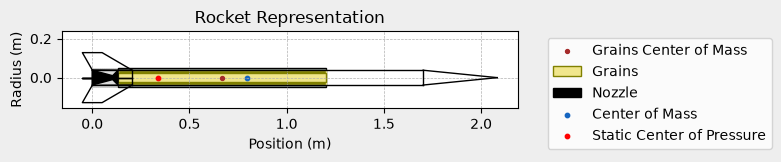


Mass Plots
----------------------------------------


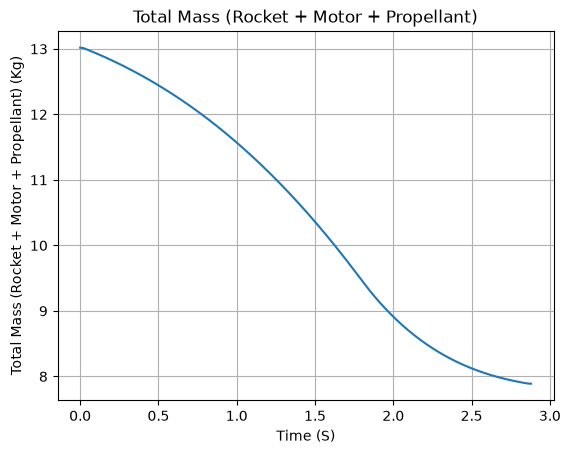

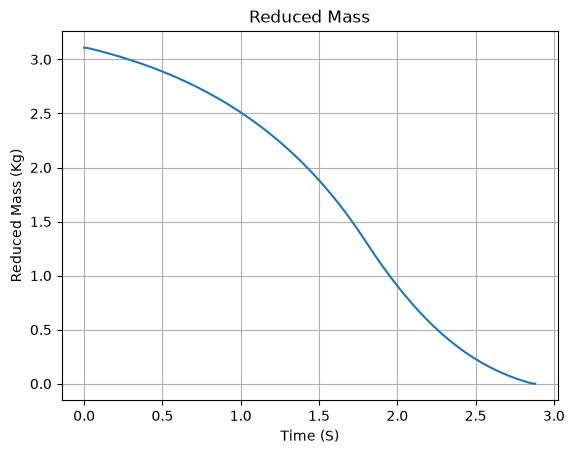


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


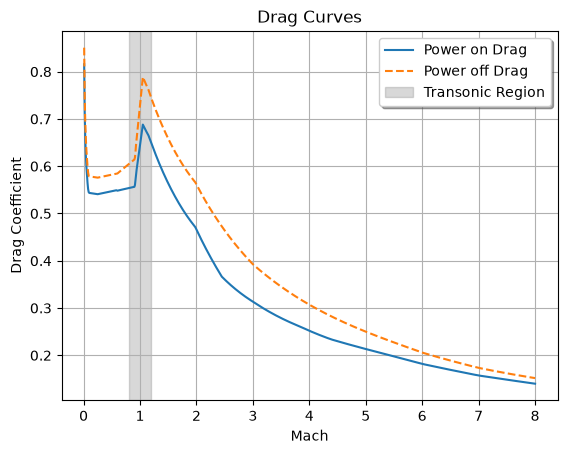


Stability Plots
--------------------


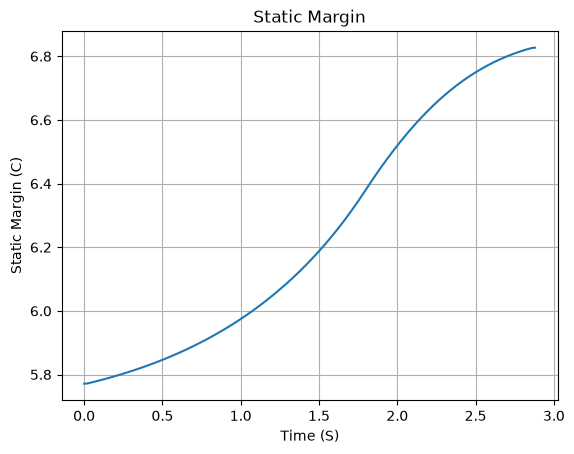

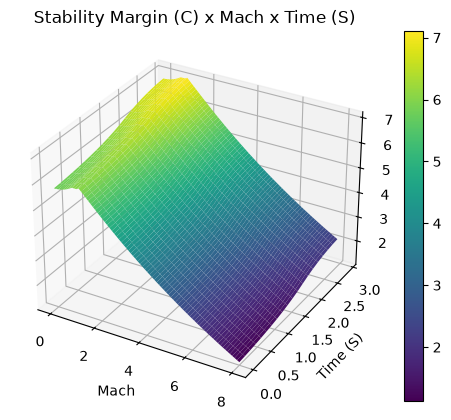


Thrust-to-Weight Plot
----------------------------------------


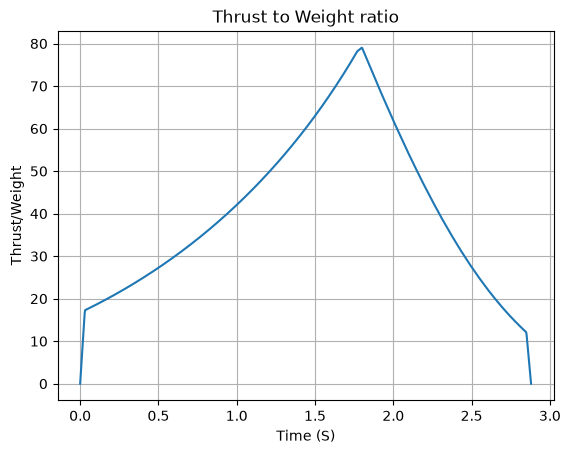

Nozzle Details
Nozzle Radius: 0.038100076000000004 m
Nozzle Throat Radius: 0.01 m

Grain Details
Number of Grains: 1
Grain Spacing: 0.0 m
Grain Density: 1799.1938061632031 kg/m3
Grain Outer Radius: 0.038100076000000004 m
Grain Inner Radius: 0.024514387715300477 m
Grain Height: 1.066802134 m
Grain Volume: 0.003 m3
Grain Mass: 5.129 kg

Motor Details
Total Burning Time: 2.88 s
Total Propellant Mass: 5.129 kg
Structural Mass Ratio: 0.002
Average Propellant Exhaust Velocity: 2304.766 m/s
Average Thrust: 4104.898 N
Maximum Thrust: 7335.7207 N at 1.8 s after ignition.
Total Impulse: 11822.105 Ns



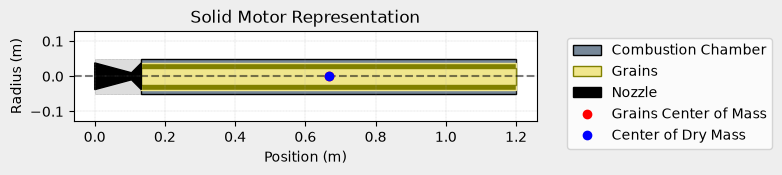

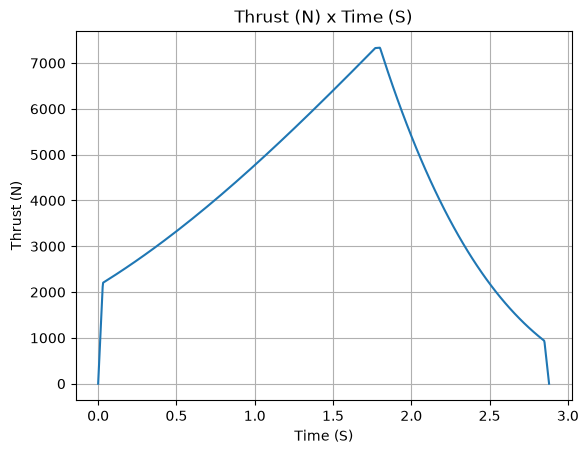

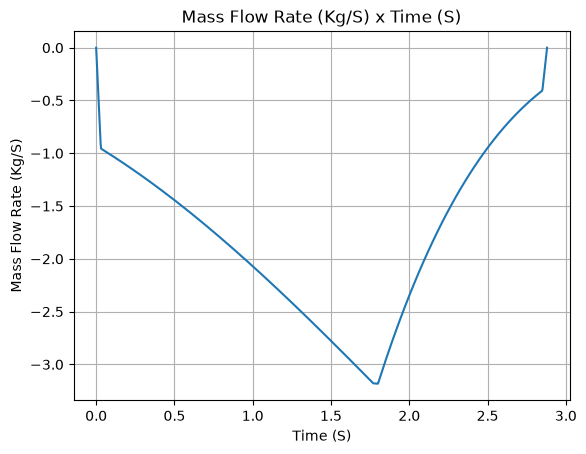

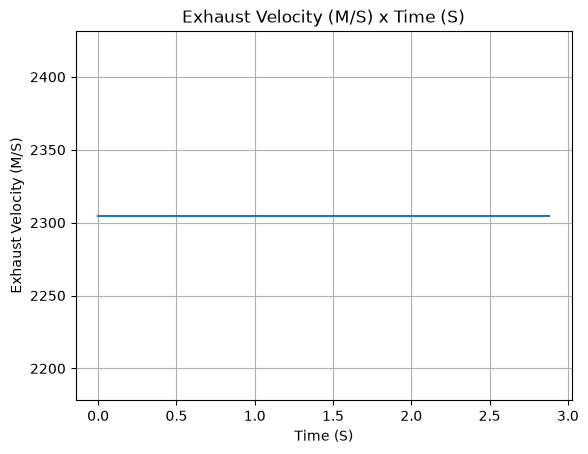

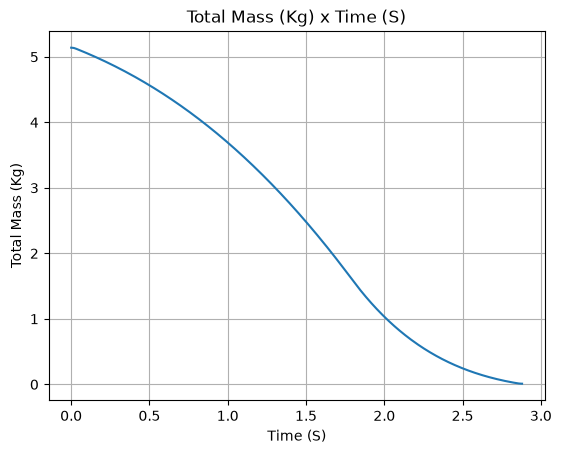

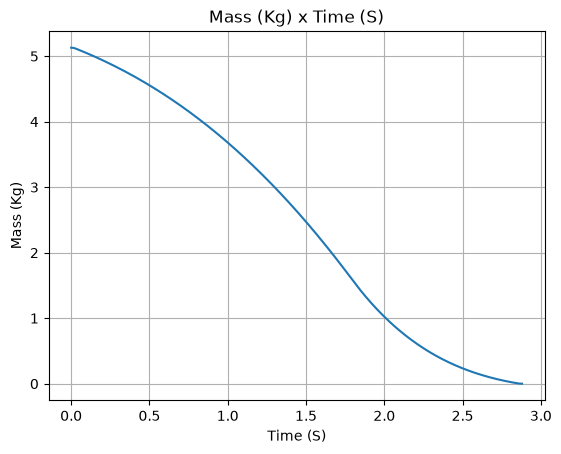

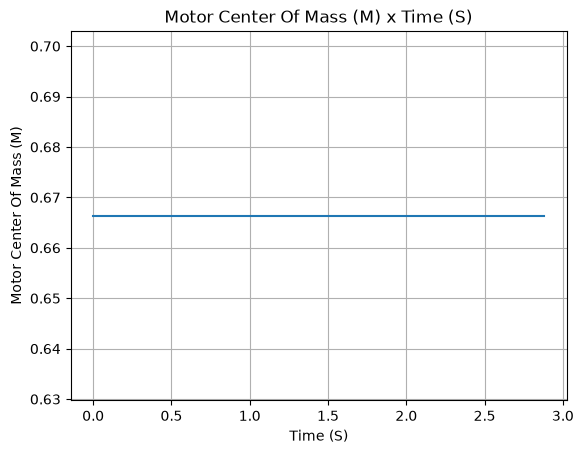

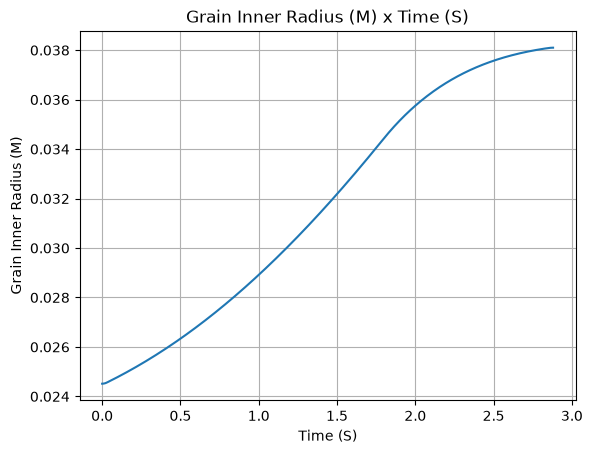

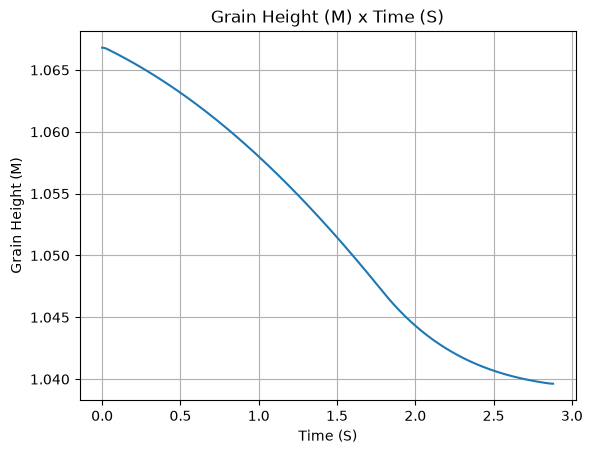

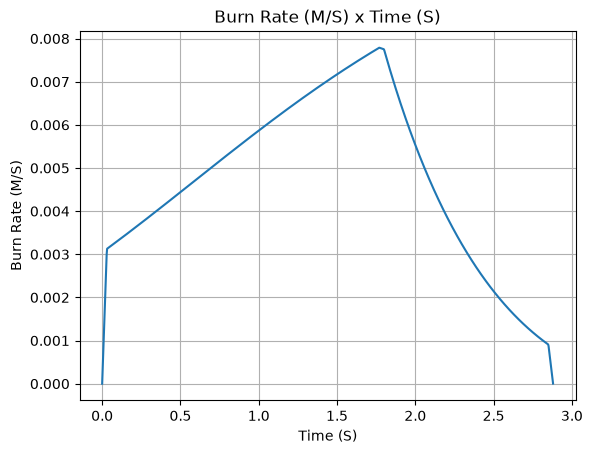

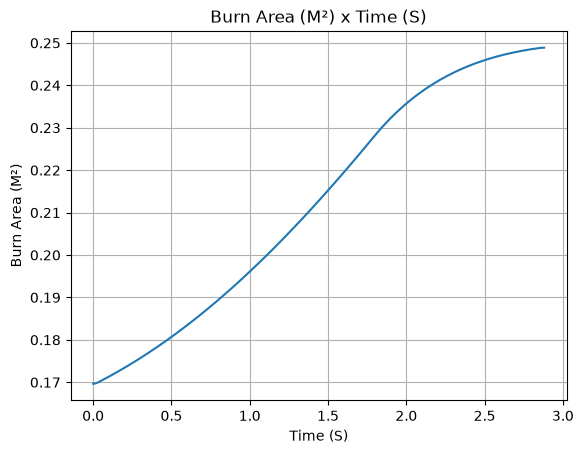

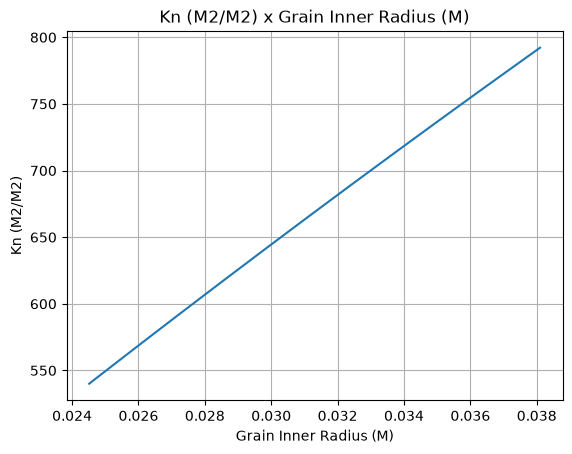

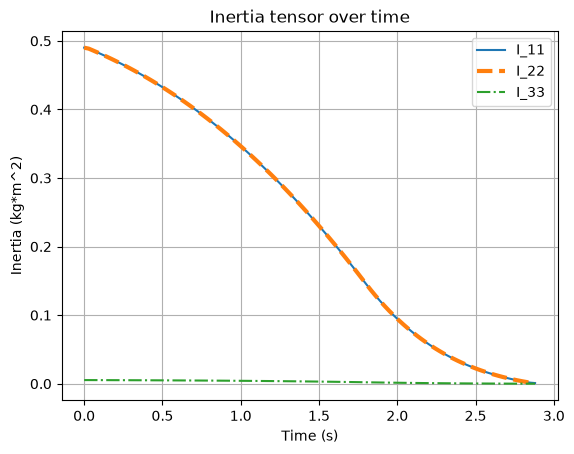

In [4]:
JSON_PATH = PROJECT_DIR / "./builtjsons/AMA 4-3 Current Booster 2024 Sustainer.json"

rocket = load_rocket(
    JSON_PATH,
    rocket_key="sustainer",
    require_simulation_ready=True,
)
rocket.all_info()

rocket.motor.all_info()
#rocket.motor.draw()

## Display all rocket information

RocketPy provides `all_info()` as the full rocket-information display call.

apogee was 48448.91609190702 ft

Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 1191.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 1.000 | e1: 0.000 | e2: 0.000 | e3: 0.000
Euler Angles - Spin φ : -180.00° | Nutation θ: 0.00° | Precession ψ: 180.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 5.771 c


Surface Wind Conditions

Frontal Surface Wind Speed: -0.67 m/s
Lateral Surface Wind Speed: -0.04 m/s


Launch Rail

Launch Rail Length: 5.2 m
Launch Rail Inclination: 90.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.262 s
Rail Departure Velocity: 44.185 m/s
Rail Departure Stability Margin: 5.810 c
Rail Departure Angle of Attack: 0.889°
Rail Departure Thrust-Weight Ratio: 21.790
Rail Departure Reynolds Number: 1.982e+05


Burn out State

Burn out time: 2.880 s
Altitude at burn out: 2653.683 m (ASL) | 1462.683 m (AGL)
Rocket speed at b

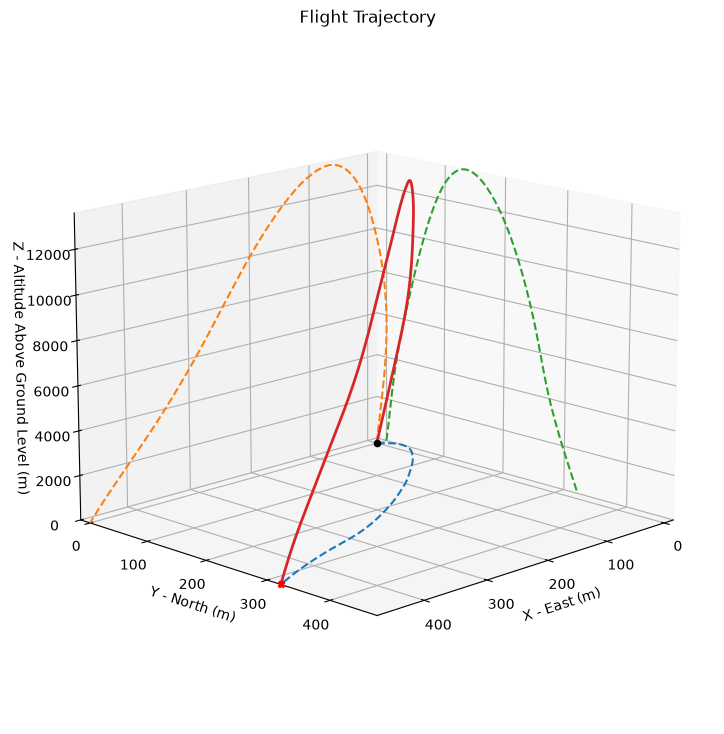

In [5]:


flight = run_single_simulation(rocket, openmeteo_result.environment)


print("apogee was " + str(flight.apogee * 3.281) + " ft")
flight.info()

flight.plots.trajectory_3d()


Inertia Details

Rocket Mass: 19.134 kg (without motor)
Rocket Dry Mass: 19.144 kg (with unloaded motor)
Rocket Loaded Mass: 29.484 kg
Rocket Structural Mass Ratio: 0.649
Rocket Inertia (with unloaded motor) 11: 19.186 kg*m2
Rocket Inertia (with unloaded motor) 22: 19.186 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.025 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0508 m
Rocket Frontal Area: 0.008107 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 1.548 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.746 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.261 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 1.125/rad
Fin Can Tail Lift Coefficient Derivative: 0.096/rad
FinCan Fins Li

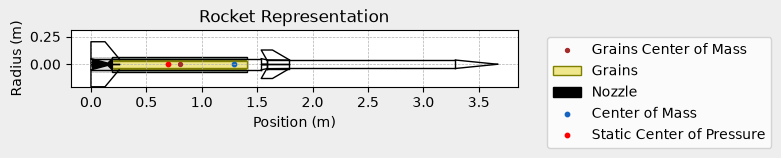

Nozzle Details
Nozzle Radius: 0.0508001015 m
Nozzle Throat Radius: 0.01 m

Grain Details
Number of Grains: 1
Grain Spacing: 0.0 m
Grain Density: 1799.1938061632031 kg/m3
Grain Outer Radius: 0.0508001015 m
Grain Inner Radius: 0.032867825418143766 m
Grain Height: 1.219202438 m
Grain Volume: 0.006 m3
Grain Mass: 10.339 kg

Motor Details
Total Burning Time: 3.18 s
Total Propellant Mass: 10.339 kg
Structural Mass Ratio: 0.001
Average Propellant Exhaust Velocity: 2322.405 m/s
Average Thrust: 7551.078 N
Maximum Thrust: 10298.0968 N at 2.026 s after ignition.
Total Impulse: 24012.427 Ns



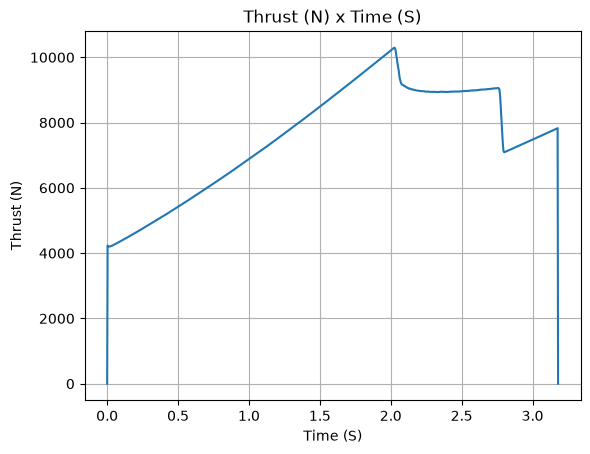

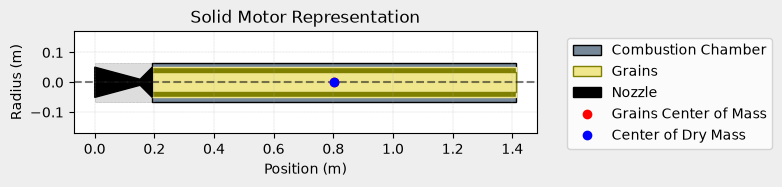


Inertia Details

Rocket Mass: 7.879 kg (without motor)
Rocket Dry Mass: 7.889 kg (with unloaded motor)
Rocket Loaded Mass: 13.018 kg
Rocket Structural Mass Ratio: 0.606
Rocket Inertia (with unloaded motor) 11: 2.853 kg*m2
Rocket Inertia (with unloaded motor) 22: 2.853 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.006 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0396875 m
Rocket Frontal Area: 0.004948 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 0.879 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.213 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.084 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 1.843/rad
Fin Can Tail Lift Coefficient Derivative: 0.157/rad
FinCan Fins Lif

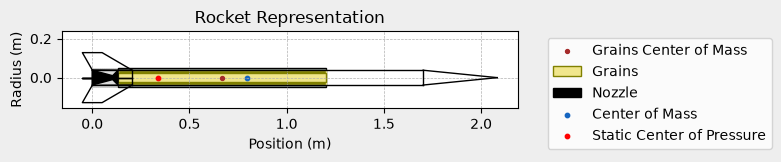

Nozzle Details
Nozzle Radius: 0.038100076000000004 m
Nozzle Throat Radius: 0.01 m

Grain Details
Number of Grains: 1
Grain Spacing: 0.0 m
Grain Density: 1799.1938061632031 kg/m3
Grain Outer Radius: 0.038100076000000004 m
Grain Inner Radius: 0.024514387715300477 m
Grain Height: 1.066802134 m
Grain Volume: 0.003 m3
Grain Mass: 5.129 kg

Motor Details
Total Burning Time: 2.88 s
Total Propellant Mass: 5.129 kg
Structural Mass Ratio: 0.002
Average Propellant Exhaust Velocity: 2304.766 m/s
Average Thrust: 4104.898 N
Maximum Thrust: 7335.7207 N at 1.8 s after ignition.
Total Impulse: 11822.105 Ns



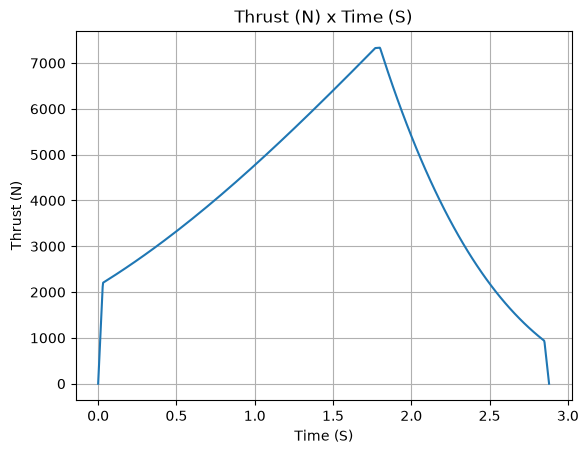

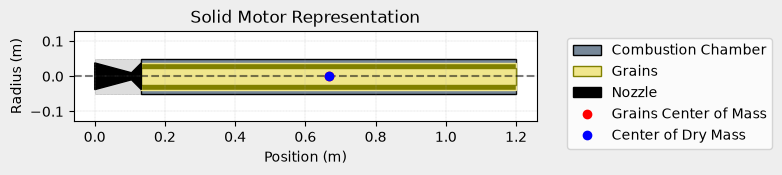

In [6]:
# Load both configurations from a version-2 JSON produced by cdx1tojson.py.
TWO_STAGE_JSON_PATH = PROJECT_DIR / ".\\builtjsons\\twostage.json"

full_stack_rocket = load_rocket(
    JSON_PATH,
    rocket_key="full_stack",
    require_simulation_ready=True,
)
sustainer_rocket = load_rocket(
    JSON_PATH,
    rocket_key="sustainer",
    require_simulation_ready=True,
)

full_stack_rocket.info()
full_stack_rocket.draw()
full_stack_rocket.motor.info()
full_stack_rocket.motor.draw()
sustainer_rocket.info()
sustainer_rocket.draw()
sustainer_rocket.motor.info()
sustainer_rocket.motor.draw()

Sustainer ignition tilt: 1.51 degrees from vertical



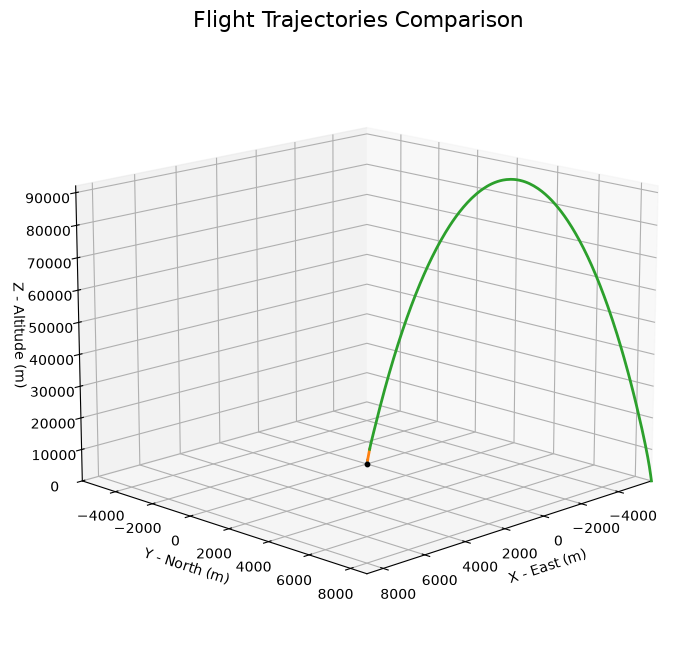

c:\Users\E\Documents\GitHub\farfromheaven\.venv\Lib\site-packages\rocketpy\plots\plot_helpers.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


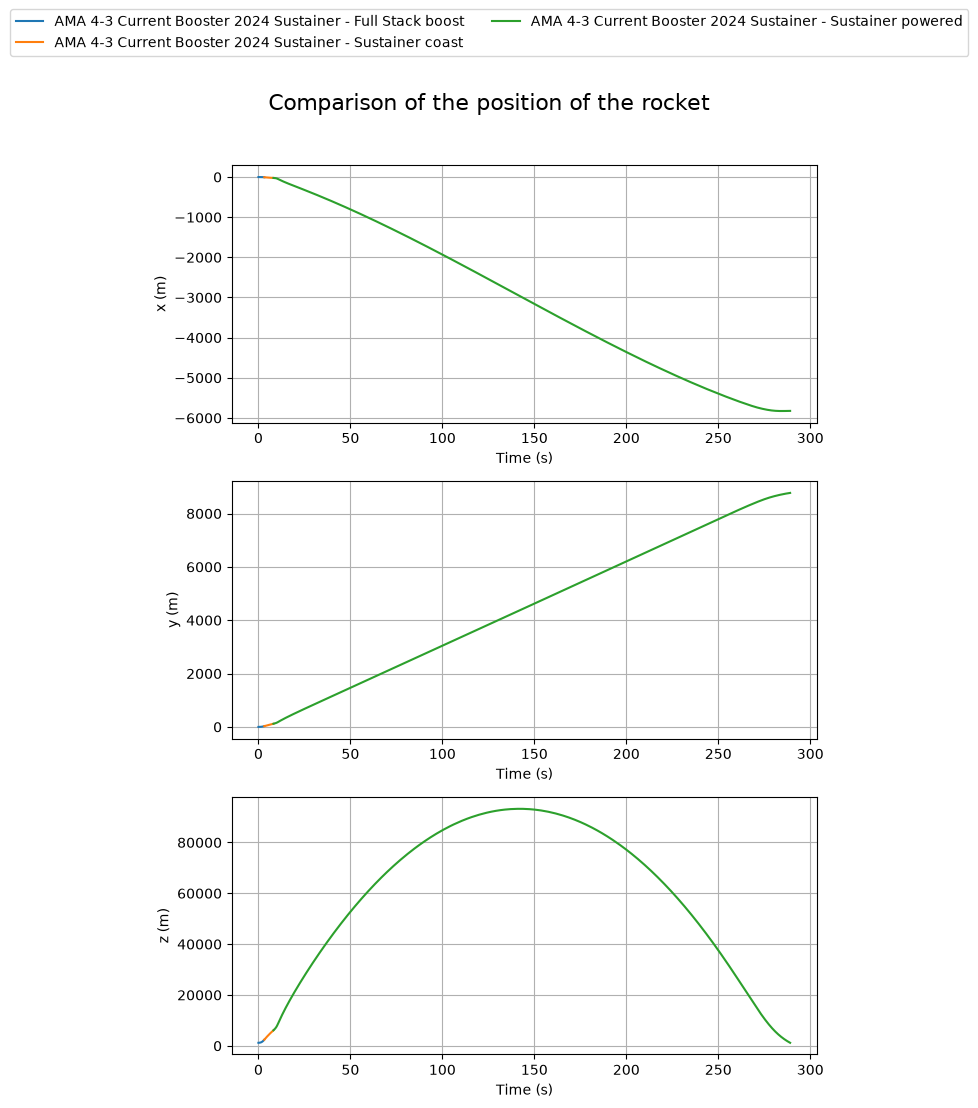

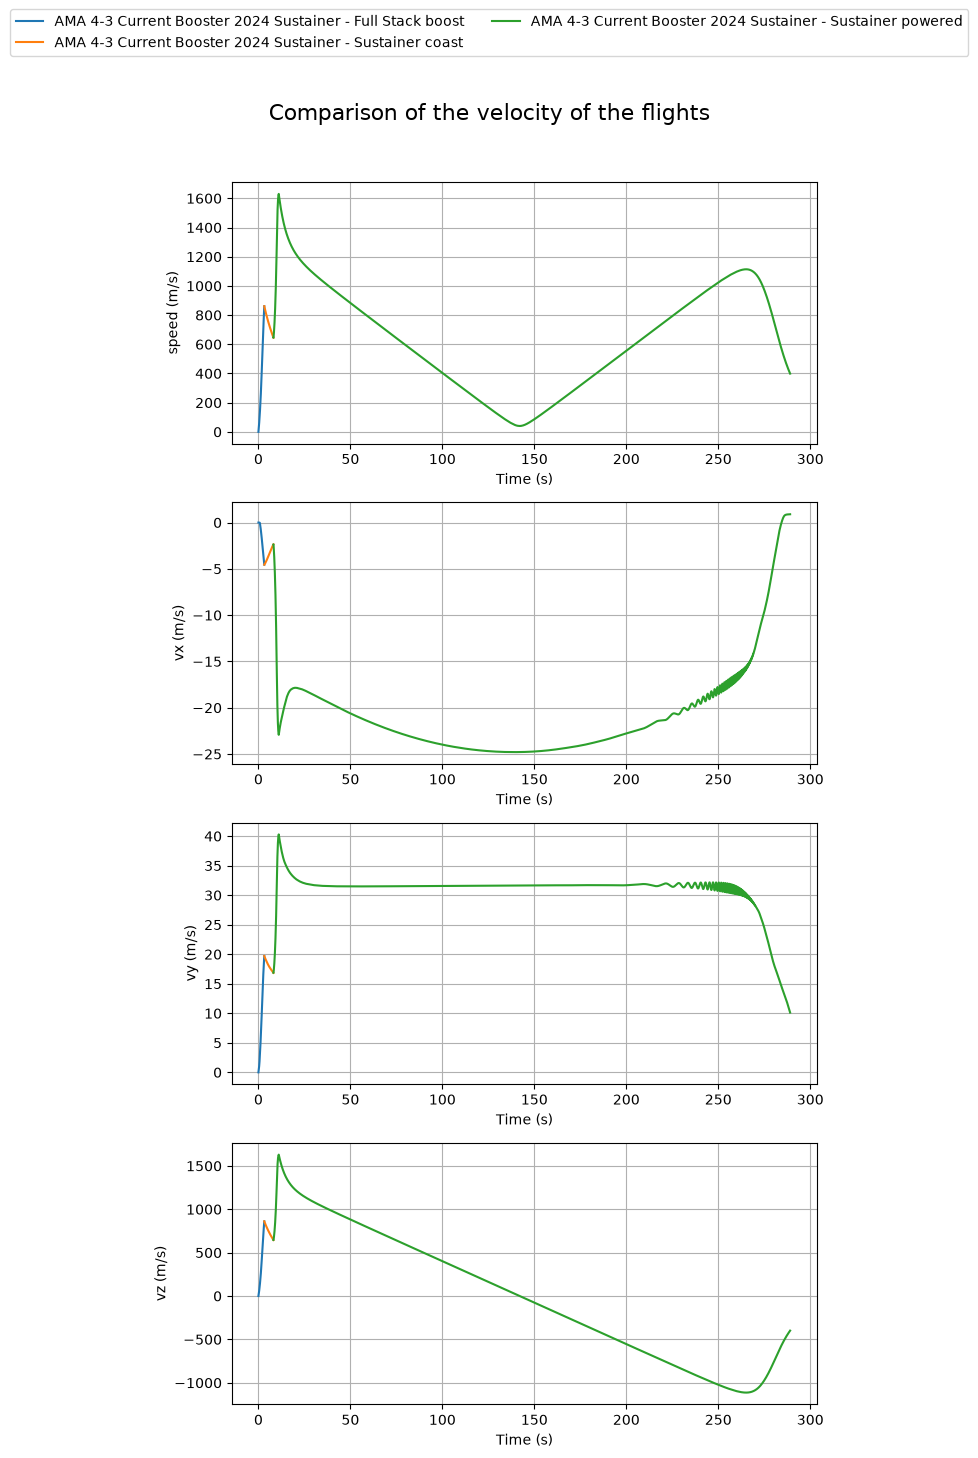

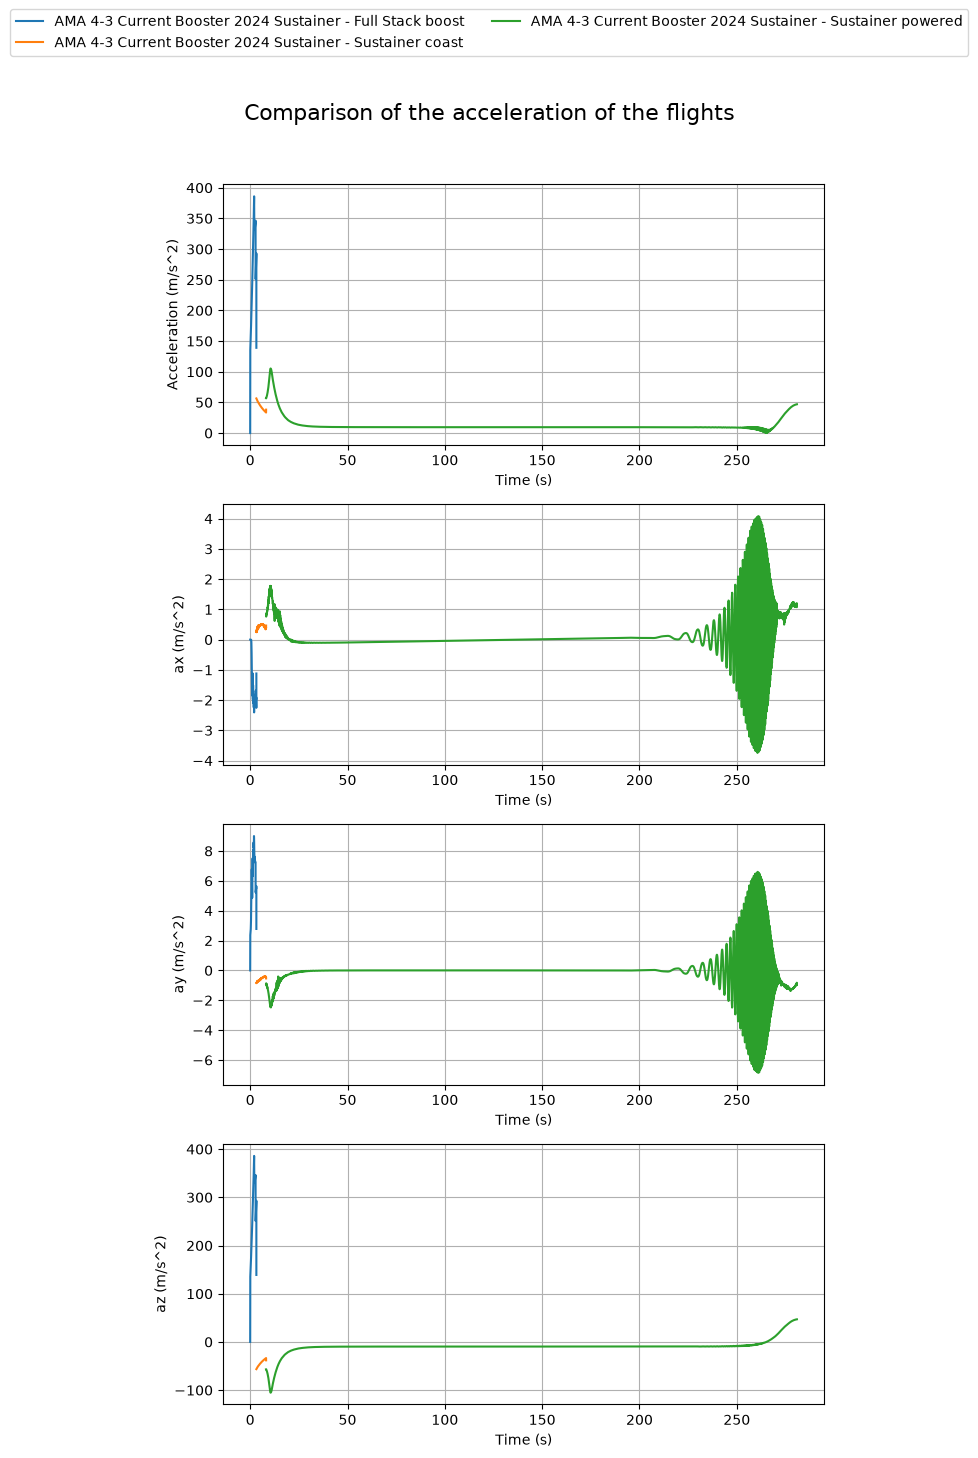

In [7]:
COAST_PERIOD = 5.0  # Seconds from booster burnout to sustainer ignition.

two_stage_solution = runfullstacksim(
    full_stack_rocket,
    sustainer_rocket,
    openmeteo_result.environment,
    time_limit=600.0,
    coast_period=COAST_PERIOD,
    rail_length=6.0,
    rod_angle=1.0,
    heading=0.0,
)


flight_comparison = CompareFlights(list(runfullstacksim.last_flights))

print()
flight_comparison.trajectories_3d()
flight_comparison.positions()
flight_comparison.velocities()
flight_comparison.accelerations()

